## Selección del mejor modelo de Machine Learning

### By:
Maria Camila Sepulveda Torres

### Date:
2026-08-21

### Description:

En este notebook se realiza el proceso de selección del mejor modelo de Machine Learning para estimar la variable objetivo `Chance of Admit`.

Partiendo del pipeline de preprocesamiento desarrollado previamente, se evaluarán diferentes modelos de regresión y se comparará su desempeño utilizando diferentes métricas.

El MAE será utilizado como métrica principal para la selección del modelo, de acuerdo con lo definido durante la construcción del modelo baseline.

Los modelos con mejor desempeño serán evaluados mediante validación cruzada y posteriormente se realizará la optimización de hiperparámetros de los mejores candidatos. Finalmente, se seleccionará el modelo con mejor capacidad de generalización y se comparará su desempeño con el modelo baseline.
Celda 2 — Markdown


## 📚 Import  libraries

In [42]:
# librerías base para ciencia de datos
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump, load
from scipy.stats import f_oneway
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

## 💾 Load data

In [43]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

admission_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admission_type_fixed.parquet",
    engine="pyarrow",
)

In [44]:
print("Versión de Pandas: ", pd.__version__)

Versión de Pandas:  3.0.5


## 👷 Data preparation or Feature Engineering

In [45]:
selected_features = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    "Chance of Admit",
]

admission_features = admission_df[selected_features].copy()

admission_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          612 non-null    Int16  
 1   TOEFL Score        604 non-null    Int16  
 2   University Rating  617 non-null    float64
 3   SOP                607 non-null    float64
 4   LOR                615 non-null    float64
 5   CGPA               621 non-null    float64
 6   Research           594 non-null    boolean
 7   Chance of Admit    623 non-null    float64
dtypes: Int16(2), boolean(1), float64(5)
memory usage: 29.3 KB


In [46]:
admission_features.isna().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

In [47]:
duplicate_rows = admission_features.duplicated().sum()

print("Número de filas duplicadas: ", duplicate_rows)

Número de filas duplicadas:  152


In [48]:
admission_features = admission_features.drop_duplicates()

admission_features.info()

<class 'pandas.DataFrame'>
Index: 471 entries, 0 to 581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          460 non-null    Int16  
 1   TOEFL Score        452 non-null    Int16  
 2   University Rating  465 non-null    float64
 3   SOP                455 non-null    float64
 4   LOR                463 non-null    float64
 5   CGPA               469 non-null    float64
 6   Research           442 non-null    boolean
 7   Chance of Admit    471 non-null    float64
dtypes: Int16(2), boolean(1), float64(5)
memory usage: 25.8 KB


## 👨‍🏭 Ingeniería de características

In [49]:
cols_numeric = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
]

cols_categoric_ord = ["Research"]

In [50]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_ord_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, cols_numeric),
        ("categoric ordinal", categorical_ord_pipe, cols_categoric_ord),
    ]
)

In [51]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

## División de datos de entrenamiento y prueba

In [52]:
# variables predictoras
X_features = admission_features.drop(columns=["Chance of Admit"]).copy()

# variable objetivo
y_target = admission_features["Chance of Admit"].copy()

X_features.shape, y_target.shape

((471, 7), (471,))

In [53]:
# 80% entrenamiento, 20% prueba
x_train, x_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=42,
)

In [54]:
x_train.shape, y_train.shape

((376, 7), (376,))

In [55]:
x_test.shape, y_test.shape

((95, 7), (95,))

## Modelos

Para realizar la selección del mejor modelo se evaluarán diferentes algoritmos de regresión. Se incluyen modelos con características y niveles de complejidad diferentes con el propósito de comparar su capacidad para estimar la variable objetivo `Chance of Admit`.

Los modelos candidatos son:

- Regresión Lineal (`LinearRegression`)
- Regresión Ridge (`Ridge`)
- Árbol de Decisión (`DecisionTreeRegressor`)
- Random Forest (`RandomForestRegressor`)
- K-Nearest Neighbors (`KNeighborsRegressor`)
- Support Vector Regression (`SVR`)

Todos los modelos serán evaluados utilizando el mismo conjunto de entrenamiento y el mismo pipeline de preprocesamiento para garantizar una comparación consistente.

## Selección inicial de modelos

In [56]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}

models

{'Linear Regression': LinearRegression(),
 'Ridge': Ridge(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'KNN': KNeighborsRegressor(),
 'SVR': SVR()}

### Función de evaluación

In [57]:
def summarize_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [58]:
def build_model(
    regressor,
    preprocessor,
    x_train,
    x_test,
    y_train,
    y_test,
):
    model_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", regressor),
        ]
    )

    model_pipe.fit(x_train, y_train)

    y_pred_train = model_pipe.predict(x_train)
    y_pred_test = model_pipe.predict(x_test)

    train_summary = summarize_regression(
        y_train,
        y_pred_train,
    )

    test_summary = summarize_regression(
        y_test,
        y_pred_test,
    )

    return {
        "train": train_summary,
        "test": test_summary,
    }

### Entrenamiento y evaluación inicial

In [59]:
result_dict = {}

for model_name, model in models.items():
    result_dict[model_name] = build_model(
        model,
        preprocessor,
        x_train,
        x_test,
        y_train,
        y_test,
    )

In [60]:
result_dict

{'Linear Regression': {'train': {'MAE': 0.045164219848514445,
   'RMSE': np.float64(0.06248703862805796),
   'R2': 0.8071365936774625},
  'test': {'MAE': 0.05153939124484444,
   'RMSE': np.float64(0.0688951450444709),
   'R2': 0.7847310409107164}},
 'Ridge': {'train': {'MAE': 0.04515429069798247,
   'RMSE': np.float64(0.062488057632703174),
   'R2': 0.807130303403073},
  'test': {'MAE': 0.05159762886854419,
   'RMSE': np.float64(0.06896401673126995),
   'R2': 0.7843004344648634}},
 'Decision Tree': {'train': {'MAE': 4.429081215259933e-18,
   'RMSE': np.float64(2.2174913625798742e-17),
   'R2': 1.0},
  'test': {'MAE': 0.04168421052631579,
   'RMSE': np.float64(0.06526061115574273),
   'R2': 0.8068447813366539}},
 'Random Forest': {'train': {'MAE': 0.01697952127659572,
   'RMSE': np.float64(0.024421132830468865),
   'R2': 0.9705421152818179},
  'test': {'MAE': 0.046356842105263224,
   'RMSE': np.float64(0.06768792086908082),
   'R2': 0.7922091010646477}},
 'KNN': {'train': {'MAE': 0.0394

### Comparación inicial de los modelos

In [61]:
results = []

for model_name, model_results in result_dict.items():
    results.append(
        {
            "Modelo": model_name,
            "Train MAE": model_results["train"]["MAE"],
            "Test MAE": model_results["test"]["MAE"],
            "Train RMSE": model_results["train"]["RMSE"],
            "Test RMSE": model_results["test"]["RMSE"],
            "Train R2": model_results["train"]["R2"],
            "Test R2": model_results["test"]["R2"],
        }
    )

results_df = pd.DataFrame(results)

results_df

,Modelo,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,4.516422e-02,0.051539,6.248704e-02,0.068895,0.807137,0.784731
1,Ridge,4.515429e-02,0.051598,6.248806e-02,0.068964,0.807130,0.784300
2,Decision Tree,4.429081e-18,0.041684,2.217491e-17,0.065261,1.000000,0.806845
3,Random Forest,1.697952e-02,0.046357,2.442113e-02,0.067688,0.970542,0.792209
4,KNN,3.943085e-02,0.054716,5.498327e-02,0.072479,0.850676,0.761750
5,SVR,5.749025e-02,0.071561,6.682118e-02,0.085486,0.779454,0.668567


In [62]:
mean_test_mae = results_df["Test MAE"].mean()

print("MAE promedio de los modelos:", mean_test_mae)

MAE promedio de los modelos: 0.05290908017980314


In [63]:
results_df["Estado"] = np.where(
    results_df["Test MAE"] <= mean_test_mae,
    "Continúa",
    "Se elimina",
)

results_df.sort_values("Test MAE")

,Modelo,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Estado
2,Decision Tree,4.429081e-18,0.041684,2.217491e-17,0.065261,1.000000,0.806845,Continúa
3,Random Forest,1.697952e-02,0.046357,2.442113e-02,0.067688,0.970542,0.792209,Continúa
0,Linear Regression,4.516422e-02,0.051539,6.248704e-02,0.068895,0.807137,0.784731,Continúa
1,Ridge,4.515429e-02,0.051598,6.248806e-02,0.068964,0.807130,0.784300,Continúa
4,KNN,3.943085e-02,0.054716,5.498327e-02,0.072479,0.850676,0.761750,Se elimina
5,SVR,5.749025e-02,0.071561,6.682118e-02,0.085486,0.779454,0.668567,Se elimina


### Comparación gráfica del desempeño inicial

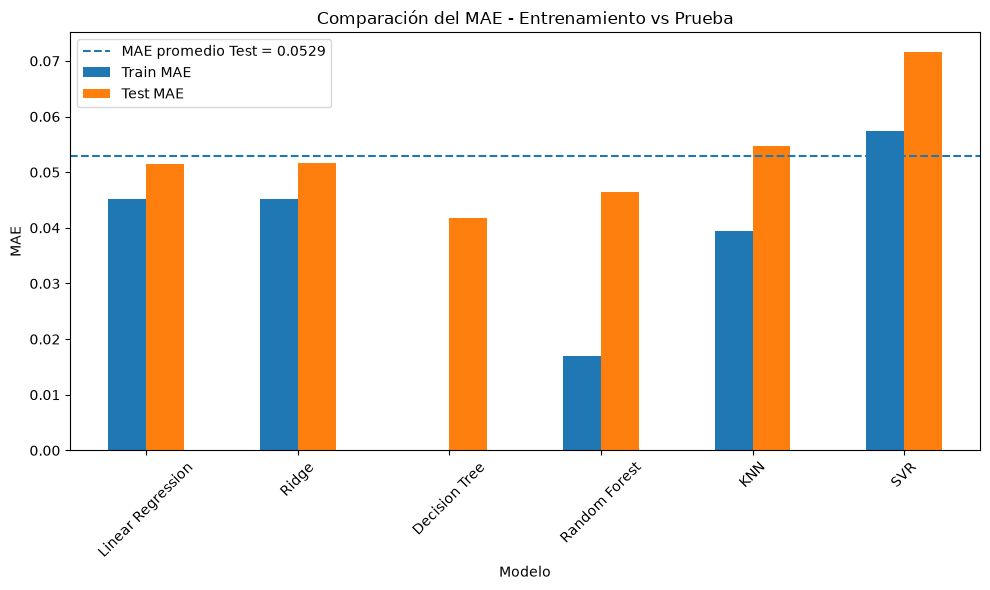

In [64]:
results_plot = results_df.set_index("Modelo")

ax = results_plot[["Train MAE", "Test MAE"]].plot(
    kind="bar",
    figsize=(10, 6),
)

ax.axhline(
    mean_test_mae,
    linestyle="--",
    label=f"MAE promedio Test = {mean_test_mae:.4f}",
)

ax.set_title("Comparación del MAE - Entrenamiento vs Prueba")
ax.set_xlabel("Modelo")
ax.set_ylabel("MAE")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comparación de RMSE entre entrenamiento y prueba

Se compara el RMSE obtenido por cada modelo en los conjuntos de entrenamiento y prueba. Adicionalmente, se representan los valores promedio de entrenamiento y prueba como referencia para facilitar la comparación entre los modelos.

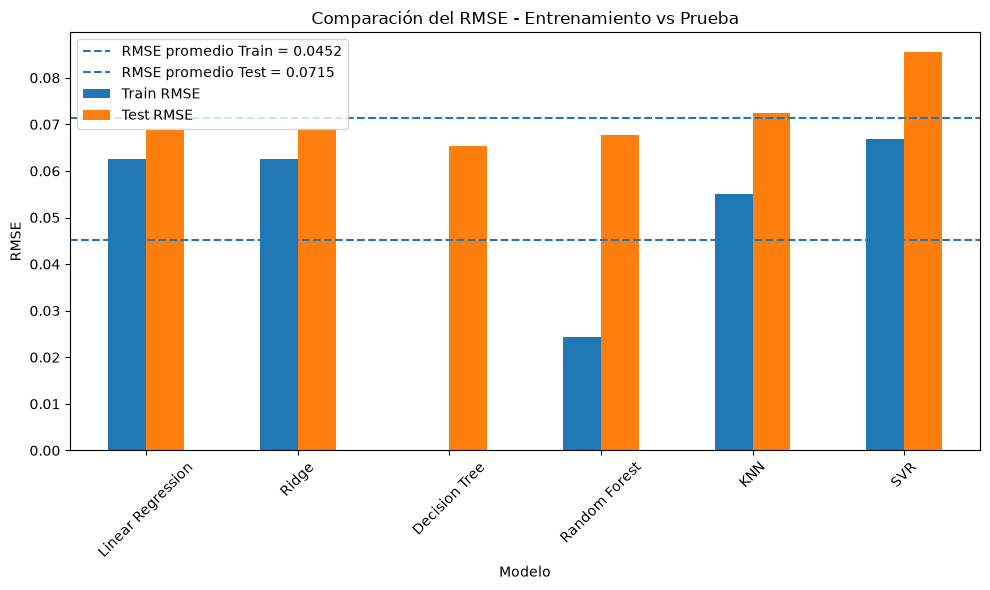

In [86]:
mean_train_rmse = results_df["Train RMSE"].mean()
mean_test_rmse = results_df["Test RMSE"].mean()

ax = results_plot[["Train RMSE", "Test RMSE"]].plot(
    kind="bar",
    figsize=(10, 6),
)

ax.axhline(
    mean_train_rmse,
    linestyle="--",
    label=f"RMSE promedio Train = {mean_train_rmse:.4f}",
)

ax.axhline(
    mean_test_rmse,
    linestyle="--",
    label=f"RMSE promedio Test = {mean_test_rmse:.4f}",
)

ax.set_title("Comparación del RMSE - Entrenamiento vs Prueba")
ax.set_xlabel("Modelo")
ax.set_ylabel("RMSE")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comparación de R² entre entrenamiento y prueba

Se compara el coeficiente de determinación R² obtenido por cada modelo en los conjuntos de entrenamiento y prueba. A diferencia de MAE y RMSE, para esta métrica los valores más altos representan un mejor ajuste del modelo.

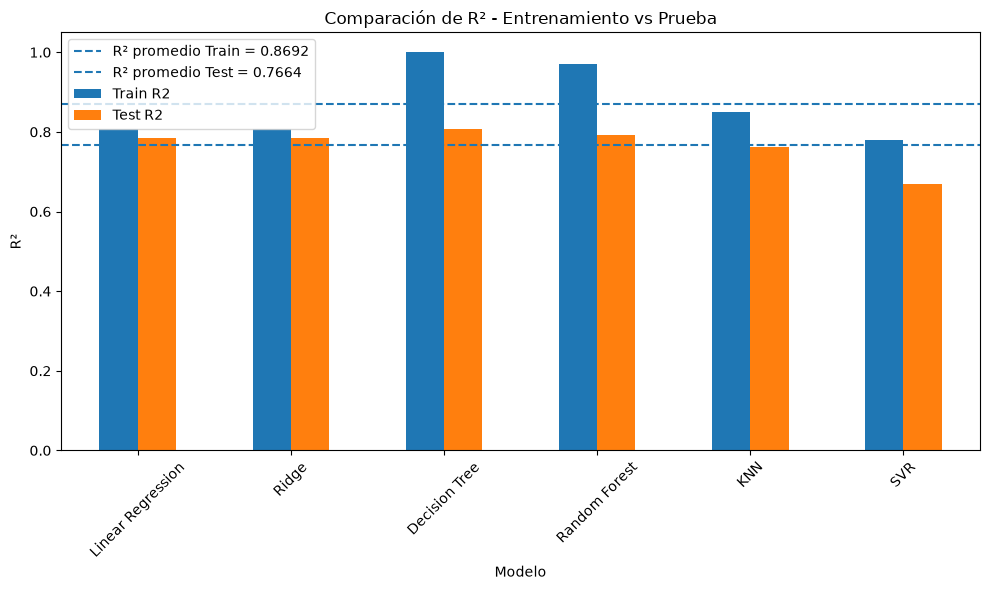

In [87]:
mean_train_r2 = results_df["Train R2"].mean()
mean_test_r2 = results_df["Test R2"].mean()

ax = results_plot[["Train R2", "Test R2"]].plot(
    kind="bar",
    figsize=(10, 6),
)

ax.axhline(
    mean_train_r2,
    linestyle="--",
    label=f"R² promedio Train = {mean_train_r2:.4f}",
)

ax.axhline(
    mean_test_r2,
    linestyle="--",
    label=f"R² promedio Test = {mean_test_r2:.4f}",
)

ax.set_title("Comparación de R² - Entrenamiento vs Prueba")
ax.set_xlabel("Modelo")
ax.set_ylabel("R²")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Selección de modelos para validación cruzada

El MAE promedio obtenido por los modelos en el conjunto de prueba fue de aproximadamente **0.0529**. Debido a que en esta métrica un valor menor representa un mejor desempeño, se descartaron los modelos cuyo MAE fue superior al promedio.

Los modelos que continúan a la etapa de validación cruzada son:

- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `LinearRegression`
- `Ridge`

Por su parte, `KNeighborsRegressor` y `SVR` se eliminan de las siguientes etapas debido a que presentaron un MAE en prueba superior al promedio de los modelos evaluados.

Aunque `DecisionTreeRegressor` obtuvo el menor MAE en el conjunto de prueba, presenta una diferencia considerable entre entrenamiento y prueba, alcanzando un R² de 1.0 y un MAE prácticamente igual a cero en entrenamiento. Este comportamiento constituye una señal de posible sobreajuste que deberá analizarse mediante validación cruzada.

## Selección de modelos mediante validación cruzada

Los modelos que superaron la primera etapa de selección serán evaluados mediante validación cruzada. Para cada modelo se utilizará un pipeline que integra el preprocesamiento de los datos y el algoritmo de regresión, evitando que las transformaciones aprendan información proveniente de los conjuntos utilizados para validación.

Se evaluarán las métricas MAE, RMSE y R². El MAE continuará siendo la métrica principal para la selección de los mejores modelos.

In [65]:
selected_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

selected_models

{'Linear Regression': LinearRegression(),
 'Ridge': Ridge(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42)}

### Validación cruzada de los modelos seleccionados

In [66]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [67]:
cv_results = {}

for model_name, model in selected_models.items():
    model_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    mae_scores = -cross_val_score(
        model_pipe,
        x_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )

    rmse_scores = -cross_val_score(
        model_pipe,
        x_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
    )

    r2_scores = cross_val_score(
        model_pipe,
        x_train,
        y_train,
        cv=cv,
        scoring="r2",
    )

    cv_results[model_name] = {
        "MAE": mae_scores,
        "RMSE": rmse_scores,
        "R2": r2_scores,
    }

In [68]:
cv_summary = []

for model_name, scores in cv_results.items():
    cv_summary.append(
        {
            "Modelo": model_name,
            "MAE promedio": scores["MAE"].mean(),
            "MAE std": scores["MAE"].std(),
            "RMSE promedio": scores["RMSE"].mean(),
            "RMSE std": scores["RMSE"].std(),
            "R2 promedio": scores["R2"].mean(),
            "R2 std": scores["R2"].std(),
        }
    )

cv_summary_df = pd.DataFrame(cv_summary).sort_values("MAE promedio")

cv_summary_df

,Modelo,MAE promedio,MAE std,RMSE promedio,RMSE std,R2 promedio,R2 std
1,Ridge,0.046864,0.005125,0.064471,0.006663,0.786061,0.049136
0,Linear Regression,0.046924,0.005085,0.064521,0.006586,0.785754,0.048907
3,Random Forest,0.047307,0.004748,0.067253,0.005891,0.770753,0.028725
2,Decision Tree,0.059522,0.005973,0.088106,0.008977,0.604899,0.070332


### Distribución del MAE en validación cruzada

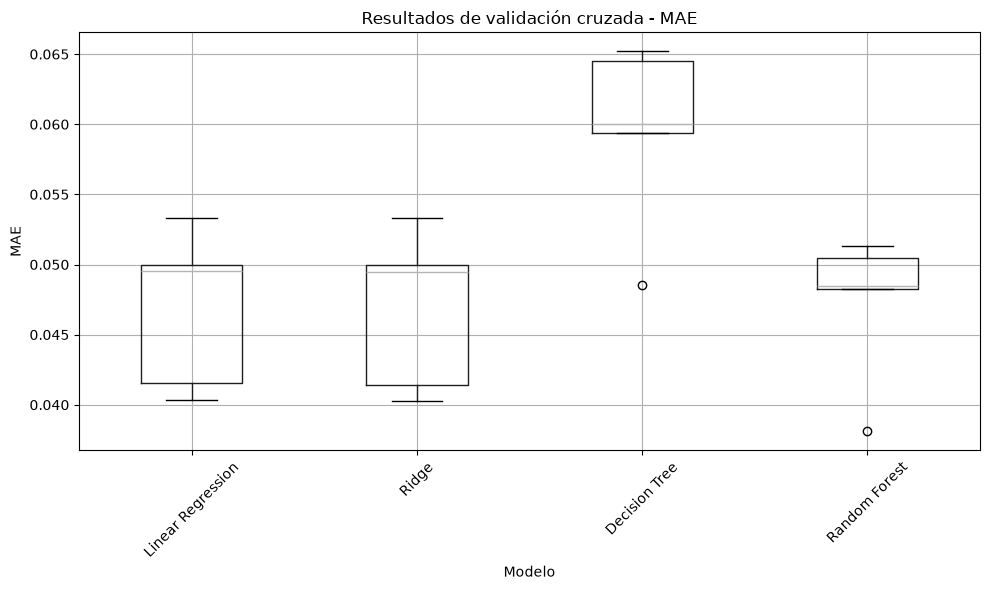

In [69]:
mae_cv_data = pd.DataFrame(
    {
        model_name: scores["MAE"]
        for model_name, scores in cv_results.items()
    }
)

ax = mae_cv_data.boxplot(
    figsize=(10, 6),
)

ax.set_title("Resultados de validación cruzada - MAE")
ax.set_xlabel("Modelo")
ax.set_ylabel("MAE")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis de la validación cruzada

Los resultados de validación cruzada muestran que `Ridge`, `LinearRegression` y `RandomForestRegressor` presentan los menores valores promedio de MAE y un comportamiento relativamente estable entre los diferentes folds.

`Ridge` obtuvo el menor MAE promedio (0.0469), seguido muy de cerca por `LinearRegression` (0.0469) y `RandomForestRegressor` (0.0473). Las diferencias observadas entre estos tres modelos son pequeñas, por lo que no es suficiente utilizar únicamente sus valores promedio para determinar cuál presenta un desempeño significativamente superior.

Por otra parte, `DecisionTreeRegressor` presentó un MAE promedio de 0.0595 y un R² promedio de 0.6049, mostrando un deterioro considerable respecto a los resultados obtenidos inicialmente sobre una única partición de prueba. Este comportamiento, junto con el desempeño prácticamente perfecto obtenido durante el entrenamiento inicial, evidencia una menor capacidad de generalización y una posible tendencia al sobreajuste.

Por esta razón, `Ridge`, `LinearRegression` y `RandomForestRegressor` continúan como los principales candidatos para las siguientes etapas del proceso de selección.

### Selección de una única métrica: MAE

Para continuar con el proceso de selección del mejor modelo se utilizará el **Error Absoluto Medio (MAE)** como métrica principal.

El MAE representa la magnitud promedio del error entre los valores reales y los valores predichos de `Chance of Admit`. Se selecciona como métrica principal porque se expresa en la misma escala de la variable objetivo, lo que facilita la interpretación directa del error de predicción.

En esta métrica, **valores menores indican un mejor desempeño**. Por esta razón, los modelos con menor MAE y mayor estabilidad durante la validación cruzada serán considerados mejores candidatos.

Las métricas RMSE y R² se mantendrán como métricas complementarias para el análisis del desempeño de los modelos.

## Comparación estadística de los modelos

Con el fin de determinar si existen diferencias estadísticamente significativas entre el desempeño de los modelos candidatos, se comparan los valores de MAE obtenidos durante la validación cruzada.

Esta comparación permite establecer si las diferencias observadas entre los valores promedio de MAE corresponden a diferencias consistentes en el desempeño de los modelos o si pueden atribuirse a la variabilidad entre los folds.

In [70]:
statistic, p_value = f_oneway(
    cv_results["Ridge"]["MAE"],
    cv_results["Linear Regression"]["MAE"],
    cv_results["Random Forest"]["MAE"],
)

print("Estadístico:", statistic)
print("p-value:", p_value)

Estadístico: 0.00926381089729318
p-value: 0.9907860443166995


### Interpretación de la comparación estadística

La prueba estadística realizada sobre los valores de MAE obtenidos mediante validación cruzada produjo un **p-value de 0.9908**, superior al nivel de significancia establecido de 0.05.

Por lo tanto, no se rechaza la hipótesis nula y no se encuentra evidencia estadísticamente significativa de diferencias en el desempeño promedio de `Ridge`, `LinearRegression` y `RandomForestRegressor` considerando el MAE obtenido en los folds de validación cruzada.

Este resultado es consistente con los valores promedio obtenidos previamente, debido a que los tres modelos presentan valores de MAE muy cercanos.

En consecuencia, no es apropiado seleccionar un modelo ganador únicamente a partir de las pequeñas diferencias observadas en el MAE promedio. Los tres modelos continuarán como candidatos para las siguientes etapas del proceso de selección.

## Optimización de hiperparámetros

A partir de los resultados obtenidos en la validación cruzada y la comparación estadística, se continúa con la optimización de los principales modelos candidatos.

La optimización se realizará utilizando validación cruzada y manteniendo integrado el pipeline de preprocesamiento, con el propósito de seleccionar las configuraciones que minimicen el MAE.

### Optimización de Ridge

In [71]:
ridge_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge()),
    ]
)

ridge_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float,

In [72]:
ridge_param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ]
}

In [73]:
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
)

In [74]:
ridge_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determine

In [75]:
print("Mejor hiperparámetro:", ridge_grid.best_params_)
print("Mejor MAE CV:", -ridge_grid.best_score_)

Mejor hiperparámetro: {'model__alpha': 10.0}
Mejor MAE CV: 0.046544314949131624


#### Resultado de la optimización de Ridge

La optimización de hiperparámetros mediante `GridSearchCV` determinó que el mejor valor para el parámetro de regularización de `Ridge` es `alpha = 10.0`.

Con esta configuración se obtuvo un MAE promedio de validación cruzada de aproximadamente **0.0465**, ligeramente inferior al MAE de **0.0469** obtenido por el modelo Ridge con su configuración inicial.

Por lo tanto, la optimización produjo una mejora moderada en el desempeño del modelo. La configuración optimizada se conservará para la comparación posterior con los demás modelos candidatos.

### Optimización de Random Forest

In [76]:
random_forest_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42)),
    ]
)

random_forest_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float,

In [77]:
random_forest_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

In [78]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipe,
    param_grid=random_forest_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
)

In [79]:
random_forest_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_s

In [80]:
print("Mejores hiperparámetros:", random_forest_grid.best_params_)
print("Mejor MAE CV:", -random_forest_grid.best_score_)

Mejores hiperparámetros: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Mejor MAE CV: 0.04720922020511202


#### Resultado de la optimización de Random Forest

La optimización de hiperparámetros mediante `GridSearchCV` determinó que la mejor configuración para `RandomForestRegressor` corresponde a `max_depth = 10`, `min_samples_leaf = 1`, `min_samples_split = 2` y `n_estimators = 100`.

Con esta configuración se obtuvo un MAE promedio de validación cruzada de aproximadamente **0.0472**, ligeramente inferior al MAE de **0.0473** obtenido con la configuración inicial.

Por lo tanto, la optimización produjo una mejora leve en el desempeño del modelo. La configuración optimizada se conservará para la comparación final con los demás modelos candidatos.

## Comparación de los modelos candidatos

Después del proceso de validación cruzada y optimización de hiperparámetros, se comparan los tres principales modelos candidatos utilizando el MAE como métrica principal.

Para `Ridge` y `RandomForestRegressor` se utilizan los resultados obtenidos con sus mejores hiperparámetros, mientras que `LinearRegression` se conserva como modelo de referencia debido a que no requiere un proceso equivalente de optimización de hiperparámetros.

In [81]:
final_candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Optimizado": Ridge(alpha=10.0),
    "Random Forest Optimizado": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
    ),
}

final_cv_results = {}

for model_name, model in final_candidate_models.items():
    model_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    mae_scores = -cross_val_score(
        model_pipe,
        x_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
    )

    final_cv_results[model_name] = mae_scores

In [82]:
final_comparison = pd.DataFrame(
    {
        "Modelo": final_cv_results.keys(),
        "MAE promedio": [
            scores.mean() for scores in final_cv_results.values()
        ],
        "Desviación estándar": [
            scores.std() for scores in final_cv_results.values()
        ],
    }
).sort_values("MAE promedio")

final_comparison

,Modelo,MAE promedio,Desviación estándar
1,Ridge Optimizado,0.046544,0.005378
0,Linear Regression,0.046924,0.005085
2,Random Forest Optimizado,0.047209,0.004548


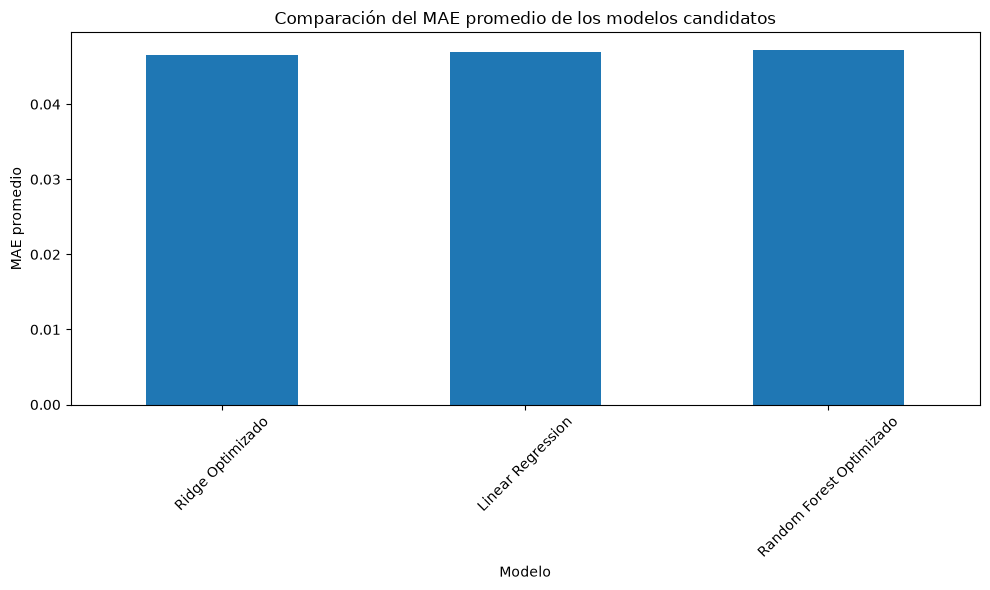

In [83]:
ax = final_comparison.plot(
    x="Modelo",
    y="MAE promedio",
    kind="bar",
    figsize=(10, 6),
    legend=False,
)

ax.set_title("Comparación del MAE promedio de los modelos candidatos")
ax.set_xlabel("Modelo")
ax.set_ylabel("MAE promedio")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

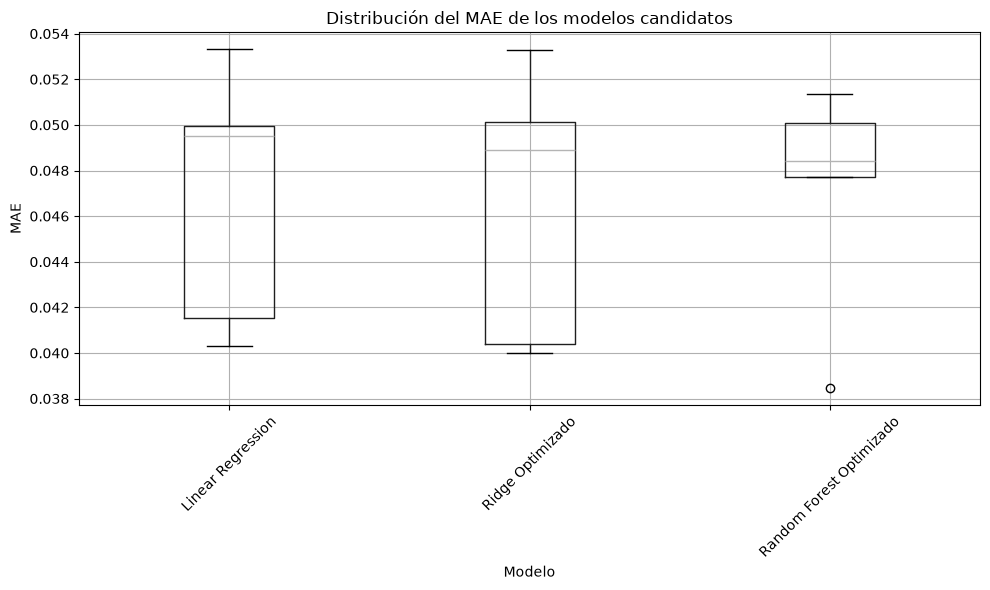

In [84]:
final_cv_df = pd.DataFrame(final_cv_results)

ax = final_cv_df.boxplot(
    figsize=(10, 6),
)

ax.set_title("Distribución del MAE de los modelos candidatos")
ax.set_xlabel("Modelo")
ax.set_ylabel("MAE")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparación estadística de los modelos optimizados

Debido a que las diferencias observadas entre los valores promedio de MAE de los modelos candidatos son pequeñas, se realiza una comparación estadística utilizando los resultados obtenidos en los mismos folds de validación cruzada.

El objetivo es determinar si las diferencias observadas entre `LinearRegression`, `Ridge` optimizado y `RandomForestRegressor` optimizado son estadísticamente significativas.

In [85]:
statistic_final, p_value_final = f_oneway(
    final_cv_results["Linear Regression"],
    final_cv_results["Ridge Optimizado"],
    final_cv_results["Random Forest Optimizado"],
)

print("Estadístico:", statistic_final)
print("p-value:", p_value_final)

Estadístico: 0.017694406410547526
p-value: 0.982486803784097


#### Interpretación de la comparación estadística final

La comparación estadística de los valores de MAE obtenidos mediante validación cruzada produjo un **p-value de 0.9825**, superior al nivel de significancia de 0.05.

Por lo tanto, no se rechaza la hipótesis nula y no se encuentra evidencia estadísticamente significativa de diferencias en el desempeño promedio de `LinearRegression`, `Ridge` optimizado y `RandomForestRegressor` optimizado.

Este resultado coincide con lo observado en las gráficas anteriores, donde los valores promedio de MAE son muy cercanos y las distribuciones obtenidas durante la validación cruzada presentan un importante grado de solapamiento.

Aunque `Ridge` optimizado obtuvo el menor MAE promedio de validación cruzada (**0.0465**), la diferencia respecto a los otros modelos candidatos no es estadísticamente significativa. Por esta razón, la selección del modelo debe considerar adicionalmente su capacidad de generalización, estabilidad y complejidad.

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


## 💡 Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project


## 📖 References